# Análisis multietiqueta de recomendaciones energéticas

Este notebook entrena un segundo modelo para **seleccionar una o varias recomendaciones** a partir de los datos de consumo y de la categoría producida por el clasificador energético.

> El dataset es simulado para el MVP. Las recomendaciones deben presentarse como orientación general, no como una certificación energética oficial.

## Objetivos

1. Explorar y validar el dataset de recomendaciones.
2. Preparar variables numéricas y categóricas.
3. Comparar regresión logística y Random Forest multietiqueta.
4. Ajustar el umbral de selección usando validación.
5. Evaluar F1, precisión, recall y Hamming Loss.
6. Exportar el pipeline y su metadata.

In [1]:
%pip install -q pandas==2.2.2 scikit-learn==1.6.1 joblib==1.5.3 matplotlib seaborn

In [2]:
from pathlib import Path
import json
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    f1_score,
    hamming_loss,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.multiclass import OneVsRestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

RANDOM_STATE = 42

In [3]:
# Funciona en Google Colab y también localmente.
try:
    from google.colab import drive
    drive.mount("/content/drive")
    EN_COLAB = True
except ImportError:
    EN_COLAB = False

CURRENT_DIR = Path.cwd()
if EN_COLAB:
    MY_DRIVE = Path("/content/drive/MyDrive")
    CANDIDATOS = [
        MY_DRIVE / "Notebook Hackathon" / "analisis-de-recomendaciones",
        MY_DRIVE / "ciencia-datos" / "analisis-de-recomendaciones",
        MY_DRIVE / "analisis-de-recomendaciones",
    ]
elif CURRENT_DIR.name == "analisis-de-recomendaciones":
    CANDIDATOS = [CURRENT_DIR]
else:
    CANDIDATOS = [
        CURRENT_DIR / "ciencia-datos" / "analisis-de-recomendaciones",
        CURRENT_DIR / "analisis-de-recomendaciones",
    ]

ANALYSIS_DIR = next(
    (ruta for ruta in CANDIDATOS if (ruta / "generar_dataset_recomendaciones.py").exists()),
    None,
)
if ANALYSIS_DIR is None:
    raise FileNotFoundError(
        "No se encontró la carpeta analisis-de-recomendaciones. "
        "Sube la carpeta completa a Mi unidad/Notebook Hackathon/."
    )

DATASET_PATH = ANALYSIS_DIR / "data" / "raw" / "recomendaciones_energia.csv"
MODEL_DIR = ANALYSIS_DIR / "models"
MODEL_PATH = MODEL_DIR / "modelo_recomendaciones.joblib"
METADATA_PATH = MODEL_DIR / "metadata_recomendaciones.json"
GENERATOR_PATH = ANALYSIS_DIR / "generar_dataset_recomendaciones.py"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

print("Entorno:", "Google Colab" if EN_COLAB else "Local")
print("Carpeta del análisis:", ANALYSIS_DIR)
print("Generador encontrado:", GENERATOR_PATH.exists())
print("Dataset:", DATASET_PATH)
print("Modelo:", MODEL_PATH)

Mounted at /content/drive
Entorno: Google Colab
Carpeta del análisis: /content/drive/MyDrive/Notebook Hackathon/analisis-de-recomendaciones
Generador encontrado: True
Dataset: /content/drive/MyDrive/Notebook Hackathon/analisis-de-recomendaciones/data/raw/recomendaciones_energia.csv
Modelo: /content/drive/MyDrive/Notebook Hackathon/analisis-de-recomendaciones/models/modelo_recomendaciones.joblib


## Generación del dataset

El paquete ya incluye el dataset simulado. Si el CSV no existe, la siguiente celda lo genera automáticamente usando el script incluido.

In [4]:
if not DATASET_PATH.exists():
    import subprocess
    import sys
    subprocess.run(
        [
            sys.executable,
            str(GENERATOR_PATH),
            "--filas",
            "6000",
            "--salida",
            str(DATASET_PATH),
        ],
        check=True,
    )

df = pd.read_csv(DATASET_PATH)
print("Dimensiones:", df.shape)
display(df.head())

Dimensiones: (6000, 32)


,id_registro,consumo_kwh,uso_horario_pico,cantidad_equipos,tipo_inmueble,horas_alto_consumo,cantidad_personas,area_m2,equipos_alto_consumo,equipos_medio_consumo,...,nivel_datos,rec_reducir_horario_pico,rec_revisar_equipos_alto_consumo,rec_optimizar_equipos_medio_consumo,rec_reducir_consumo_en_espera,rec_optimizar_aire_acondicionado,rec_reducir_consumo_por_persona,rec_monitorear_incremento_mensual,rec_mejorar_eficiencia_inmueble,rec_mantener_habitos
0,1,911.7,True,22,Comercio,8.4,NaN,NaN,6,9,...,basico,1,0,1,0,0,0,0,0,0
1,2,3582.8,True,400,Apartamento,24.0,NaN,NaN,37,120,...,basico,1,0,1,1,0,0,0,1,0
2,3,481.7,True,16,Comercio,8.5,NaN,86.0,2,7,...,parcial,1,0,1,0,0,0,0,0,0
3,4,201.7,True,4,Apartamento,3.3,1.0,70.0,0,1,...,avanzado,1,0,0,1,1,0,0,0,0
4,5,549.4,True,18,Casa,7.1,5.0,70.0,3,7,...,avanzado,1,0,1,0,1,0,1,1,0


In [5]:
FEATURE_COLUMNS = [
    "consumo_kwh",
    "uso_horario_pico",
    "cantidad_equipos",
    "tipo_inmueble",
    "horas_alto_consumo",
    "cantidad_personas",
    "area_m2",
    "equipos_alto_consumo",
    "horas_aire_acondicionado",
    "consumo_mes_anterior_kwh",
    "dias_facturados",
    "consumo_por_persona",
    "consumo_por_m2",
    "variacion_mensual",
    "proporcion_equipos_alto_consumo",
    "categoria",
]

TARGET_COLUMNS = [
    "rec_reducir_horario_pico",
    "rec_revisar_equipos_alto_consumo",
    "rec_optimizar_aire_acondicionado",
    "rec_reducir_consumo_por_persona",
    "rec_monitorear_incremento_mensual",
    "rec_mejorar_eficiencia_inmueble",
    "rec_mantener_habitos",
]

CATALOGO_RECOMENDACIONES = {
    "rec_reducir_horario_pico": "Distribuir, cuando sea posible, el consumo fuera de los horarios de mayor demanda",
    "rec_revisar_equipos_alto_consumo": "Identificar las principales fuentes de consumo y priorizar acciones de eficiencia energética",
    "rec_optimizar_aire_acondicionado": "Reducir consumos innecesarios y ajustar la duración de las actividades de mayor demanda",
    "rec_reducir_consumo_por_persona": "Promover hábitos de ahorro y dar seguimiento continuo al consumo",
    "rec_monitorear_incremento_mensual": "Comparar periódicamente el consumo para detectar cambios y oportunidades de ahorro",
    "rec_mejorar_eficiencia_inmueble": "Aplicar mejoras graduales que aumenten la eficiencia energética general",
    "rec_mantener_habitos": "Mantener los buenos hábitos y monitorear el consumo periódicamente",
}

columnas_faltantes = set(FEATURE_COLUMNS + TARGET_COLUMNS) - set(df.columns)
if columnas_faltantes:
    raise ValueError(f"Faltan columnas: {sorted(columnas_faltantes)}")

## Exploración y calidad de datos

In [6]:
print("Duplicados:", df.duplicated().sum())
print("\nNulos por variable de entrada:")
display(df[FEATURE_COLUMNS].isna().mean().sort_values(ascending=False).round(4))
print("\nNulos en etiquetas:", int(df[TARGET_COLUMNS].isna().sum().sum()))
print("\nCategorías energéticas:")
display(df["categoria"].value_counts(normalize=True).round(4))
print("\nNiveles de disponibilidad:")
display(df["nivel_datos"].value_counts(normalize=True).round(4))

Duplicados: 0

Nulos por variable de entrada:


,0
cantidad_personas,0.4240
consumo_por_persona,0.4240
horas_aire_acondicionado,0.4228
consumo_mes_anterior_kwh,0.4220
variacion_mensual,0.4220
area_m2,0.4212
consumo_por_m2,0.4212
dias_facturados,0.4207
equipos_alto_consumo,0.0000
horas_alto_consumo,0.0000



Nulos en etiquetas: 0

Categorías energéticas:


,proportion
categoria,
Moderado,0.34
Eficiente,0.34
Ineficiente,0.32



Niveles de disponibilidad:


,proportion
nivel_datos,
avanzado,0.4507
basico,0.2935
parcial,0.2558


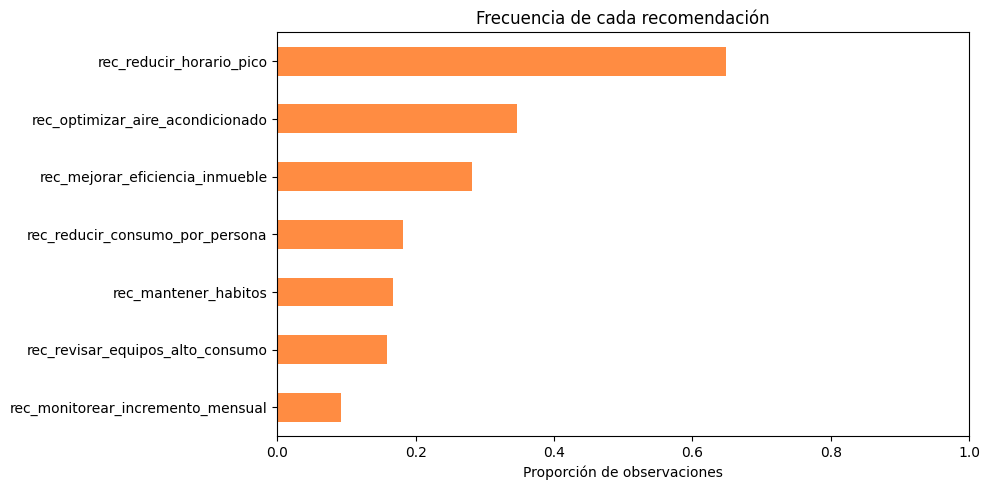

,0
rec_monitorear_incremento_mensual,0.0912
rec_revisar_equipos_alto_consumo,0.1578
rec_mantener_habitos,0.1677
rec_reducir_consumo_por_persona,0.1818
rec_mejorar_eficiencia_inmueble,0.2808
rec_optimizar_aire_acondicionado,0.3468
rec_reducir_horario_pico,0.6483


In [7]:
frecuencias = df[TARGET_COLUMNS].mean().sort_values()
plt.figure(figsize=(10, 5))
frecuencias.plot(kind="barh", color="#ff8c42")
plt.title("Frecuencia de cada recomendación")
plt.xlabel("Proporción de observaciones")
plt.xlim(0, 1)
plt.tight_layout()
plt.show()
display(frecuencias.round(4))

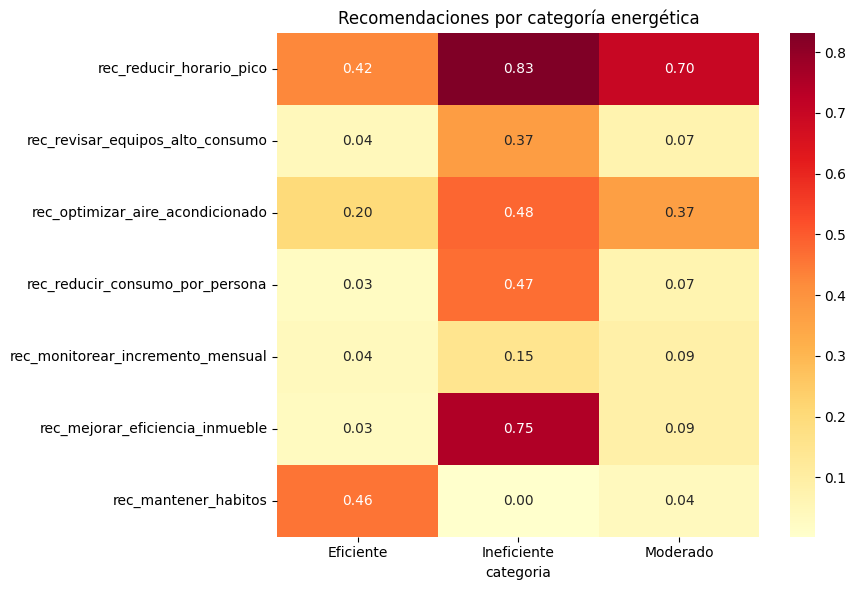

In [8]:
perfil_categoria = df.groupby("categoria")[TARGET_COLUMNS].mean().T
plt.figure(figsize=(9, 6))
sns.heatmap(perfil_categoria, annot=True, fmt=".2f", cmap="YlOrRd")
plt.title("Recomendaciones por categoría energética")
plt.tight_layout()
plt.show()

## Preparación y división

La división conserva aproximadamente la combinación de categoría energética y nivel de datos. El conjunto de prueba queda aislado hasta la evaluación final.

In [9]:
X = df[FEATURE_COLUMNS].copy()
X["uso_horario_pico"] = X["uso_horario_pico"].astype(int)
y = df[TARGET_COLUMNS].astype(int)

estratos = df["categoria"].astype(str) + "_" + df["nivel_datos"].astype(str)
indices_train, indices_temporales = train_test_split(
    df.index,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=estratos,
)
indices_validacion, indices_test = train_test_split(
    indices_temporales,
    test_size=0.50,
    random_state=RANDOM_STATE,
    stratify=estratos.loc[indices_temporales],
)

X_train, y_train = X.loc[indices_train], y.loc[indices_train]
X_validacion, y_validacion = X.loc[indices_validacion], y.loc[indices_validacion]
X_test, y_test = X.loc[indices_test], y.loc[indices_test]

print("Entrenamiento:", X_train.shape)
print("Validación:", X_validacion.shape)
print("Prueba:", X_test.shape)

Entrenamiento: (4200, 16)
Validación: (900, 16)
Prueba: (900, 16)


In [10]:
CATEGORICAL_FEATURES = ["tipo_inmueble", "categoria"]
NUMERIC_FEATURES = [
    columna for columna in FEATURE_COLUMNS
    if columna not in CATEGORICAL_FEATURES
]

numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)
categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore")),
    ]
)
preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_pipeline, NUMERIC_FEATURES),
        ("categorical", categorical_pipeline, CATEGORICAL_FEATURES),
    ]
)

In [11]:
def calcular_metricas(y_real, probabilidades, umbral):
    predicciones = (probabilidades >= umbral).astype(int)
    return {
        "precision_micro": float(precision_score(y_real, predicciones, average="micro", zero_division=0)),
        "recall_micro": float(recall_score(y_real, predicciones, average="micro", zero_division=0)),
        "f1_micro": float(f1_score(y_real, predicciones, average="micro", zero_division=0)),
        "f1_macro": float(f1_score(y_real, predicciones, average="macro", zero_division=0)),
        "hamming_loss": float(hamming_loss(y_real, predicciones)),
    }

def buscar_umbral(y_real, probabilidades):
    candidatos = np.arange(0.30, 0.71, 0.05)
    return max(
        candidatos,
        key=lambda umbral: f1_score(
            y_real,
            (probabilidades >= umbral).astype(int),
            average="macro",
            zero_division=0,
        ),
    )

## Entrenamiento y selección

`OneVsRestClassifier` entrena un clasificador binario por recomendación y permite devolver varias acciones simultáneamente.

In [12]:
modelos = {
    "regresion_logistica": OneVsRestClassifier(
        LogisticRegression(
            max_iter=2500,
            class_weight="balanced",
            random_state=RANDOM_STATE,
        )
    ),
    "random_forest": OneVsRestClassifier(
        RandomForestClassifier(
            n_estimators=250,
            max_depth=14,
            min_samples_leaf=3,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )
    ),
}

pipelines = {}
resultados_validacion = {}

for nombre, modelo in modelos.items():
    pipeline = Pipeline(
        steps=[
            ("preprocessor", clone(preprocessor)),
            ("classifier", modelo),
        ]
    )
    pipeline.fit(X_train, y_train)
    probabilidades = pipeline.predict_proba(X_validacion)
    umbral = float(buscar_umbral(y_validacion, probabilidades))
    metricas = calcular_metricas(y_validacion, probabilidades, umbral)
    metricas["umbral"] = umbral
    pipelines[nombre] = pipeline
    resultados_validacion[nombre] = metricas

display(pd.DataFrame(resultados_validacion).T.sort_values("f1_macro", ascending=False))

,precision_micro,recall_micro,f1_micro,f1_macro,hamming_loss,umbral
random_forest,0.940818,0.900701,0.920322,0.896879,0.042381,0.55
regresion_logistica,0.903667,0.849299,0.875640,0.838580,0.065556,0.70


In [13]:
nombre_mejor_modelo = max(
    resultados_validacion,
    key=lambda nombre: resultados_validacion[nombre]["f1_macro"],
)
mejor_pipeline = pipelines[nombre_mejor_modelo]
UMBRAL = resultados_validacion[nombre_mejor_modelo]["umbral"]

probabilidades_test = mejor_pipeline.predict_proba(X_test)
predicciones_test = (probabilidades_test >= UMBRAL).astype(int)
metricas_test = calcular_metricas(y_test, probabilidades_test, UMBRAL)

print("Modelo seleccionado:", nombre_mejor_modelo)
print("Umbral:", UMBRAL)
display(pd.Series(metricas_test))
print("\nReporte por recomendación:")
print(classification_report(
    y_test,
    predicciones_test,
    target_names=TARGET_COLUMNS,
    zero_division=0,
))

Modelo seleccionado: random_forest
Umbral: 0.5499999999999999


,0
precision_micro,0.927906
recall_micro,0.888162
f1_micro,0.907599
f1_macro,0.878689
hamming_loss,0.048254



Reporte por recomendación:
                                   precision    recall  f1-score   support

         rec_reducir_horario_pico       0.97      0.98      0.98       570
 rec_revisar_equipos_alto_consumo       0.93      0.72      0.81       151
 rec_optimizar_aire_acondicionado       0.95      0.87      0.90       306
  rec_reducir_consumo_por_persona       0.95      0.91      0.93       160
rec_monitorear_incremento_mensual       0.98      0.74      0.84        80
  rec_mejorar_eficiencia_inmueble       0.91      0.85      0.88       260
             rec_mantener_habitos       0.74      0.88      0.80       154

                        micro avg       0.93      0.89      0.91      1681
                        macro avg       0.92      0.85      0.88      1681
                     weighted avg       0.93      0.89      0.91      1681
                      samples avg       0.87      0.84      0.84      1681



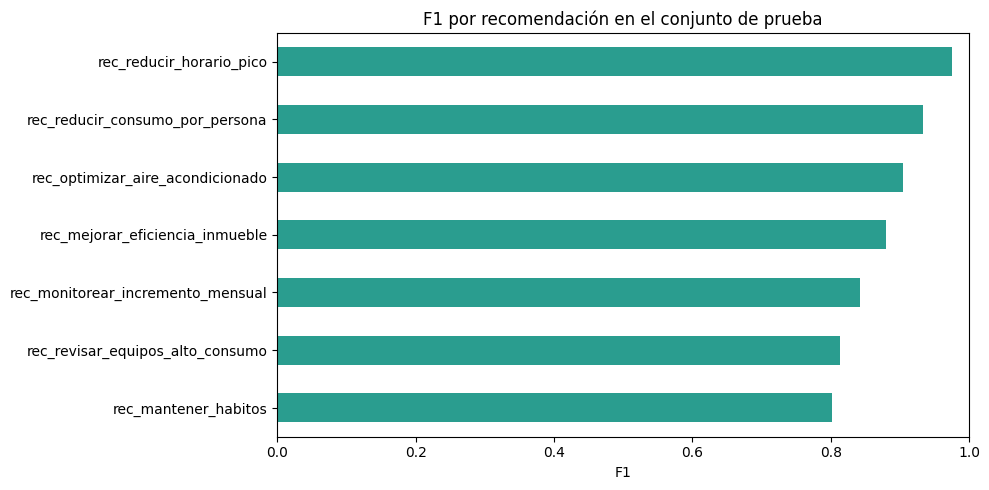

In [14]:
f1_por_recomendacion = pd.Series(
    f1_score(y_test, predicciones_test, average=None, zero_division=0),
    index=TARGET_COLUMNS,
).sort_values()
plt.figure(figsize=(10, 5))
f1_por_recomendacion.plot(kind="barh", color="#2a9d8f")
plt.title("F1 por recomendación en el conjunto de prueba")
plt.xlabel("F1")
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

## Ejemplo de inferencia

Los campos avanzados ausentes se dejan como `NaN`; el pipeline los imputa. En producción, `categoria` vendrá del primer modelo.

In [18]:
ejemplo_basico = {
    "consumo_kwh": 420.0,
    "uso_horario_pico": 1,
    "cantidad_equipos": 10,
    "tipo_inmueble": "Casa",
    "horas_alto_consumo": 8.0,
    "categoria": "Moderado",
}
entrada_ejemplo = pd.DataFrame([ejemplo_basico]).reindex(columns=FEATURE_COLUMNS)
probabilidades_ejemplo = mejor_pipeline.predict_proba(entrada_ejemplo)[0]
seleccionadas = np.flatnonzero(probabilidades_ejemplo >= UMBRAL)
if len(seleccionadas) == 0:
    seleccionadas = np.array([int(np.argmax(probabilidades_ejemplo))])

resultado_ejemplo = [
    {
        "codigo": TARGET_COLUMNS[indice],
        "texto": CATALOGO_RECOMENDACIONES[TARGET_COLUMNS[indice]],
        "confianza": round(float(probabilidades_ejemplo[indice]), 4),
    }
    for indice in seleccionadas
]
display(resultado_ejemplo)

[{'codigo': 'rec_reducir_horario_pico',
  'texto': 'Distribuir, cuando sea posible, el consumo fuera de los horarios de mayor demanda',
  'confianza': 0.9577}]

## Exportación del pipeline y metadata

In [19]:
joblib.dump(mejor_pipeline, MODEL_PATH)

metadata = {
    "nombre": "recomendador-energia-multietiqueta",
    "version": "1.1.0",
    "modelo_seleccionado": nombre_mejor_modelo,
    "columnas_entrada": FEATURE_COLUMNS,
    "columnas_objetivo": TARGET_COLUMNS,
    "umbral": UMBRAL,
    "metricas_validacion": resultados_validacion[nombre_mejor_modelo],
    "metricas_prueba": metricas_test,
    "catalogo_recomendaciones": CATALOGO_RECOMENDACIONES,
    "dataset_simulado": True,
}
with open(METADATA_PATH, "w", encoding="utf-8") as archivo:
    json.dump(metadata, archivo, indent=2, ensure_ascii=False)

print("Modelo guardado en:", MODEL_PATH)
print("Metadata guardada en:", METADATA_PATH)

Modelo guardado en: /content/drive/MyDrive/Notebook Hackathon/analisis-de-recomendaciones/models/modelo_recomendaciones.joblib
Metadata guardada en: /content/drive/MyDrive/Notebook Hackathon/analisis-de-recomendaciones/models/metadata_recomendaciones.json


In [20]:
modelo_recargado = joblib.load(MODEL_PATH)
with open(METADATA_PATH, encoding="utf-8") as archivo:
    metadata_recargada = json.load(archivo)

probabilidades_recargadas = modelo_recargado.predict_proba(entrada_ejemplo)[0]
assert np.allclose(probabilidades_ejemplo, probabilidades_recargadas)
assert metadata_recargada["columnas_entrada"] == FEATURE_COLUMNS
assert metadata_recargada["columnas_objetivo"] == TARGET_COLUMNS

print("Modelo recargado: APROBADO")
print("Metadata recargada: APROBADO")
print("F1 macro de prueba:", round(metricas_test["f1_macro"], 4))

Modelo recargado: APROBADO
Metadata recargada: APROBADO
F1 macro de prueba: 0.8787
